# Monday, March 9th, 2026

Last week we spent more time working with `numpy` arrays and plotting with `matplotlib.pyplot`. Let's start by importing both modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### An example using NumPy slicing



We saw that taking slices of NumPy arrays produced *views* of the array, where changes made to the slice would propogate back to the original arrray.

One takeaway from this is that we can use slices of an array to make assignments to portions of an array.

**Exercise:** Consider the [*Sieve of Eratosthenes*](https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes), which is a method of identifying all prime numbers up to a designated maximum. Write a function `sieve_of_Eratosthenes(N)` that implements this algorithm (using NumPy slicing) to generate an array of all primes less than or equal to `N`.

Strategy:

We will intialize `is_prime` to be an array of length `N+1` that contains `True` in every position. Our goal is to modify `is_prime` so that we have `is_prime` set to `True` exactly when `i` is a prime number (and `False` if not). We will do so using the Sieve of Eratosthenes. That is, we will:
 - Iterate `n` through integers `2` up to `N` using a `for` loop.
 - If we've not yet shown that `n` is not prime, then it must be prime and we will add it to our list of primes. We will then set `is_prime[i] = False` for all indices `i` that are a multiple of `n` (other than `i=n`). That is, we set `is_prime[i] = False` for indices `i = 2*n`, `i=3*n`, `i=4*n`, etc.
 - If `n` is not prime (that is, if `is_prime[n] == False`), do nothing and skip to the next iteration.
 - After completing the `for` loop, return the list of integers `n` for which `is_prime[n]` set to `True`.

In [19]:
def sieve_of_Eratosthenes(N):
    primes = []
    is_prime = np.ones(N+1, dtype=bool)
    is_prime[0] = False
    is_prime[1] = False
    
    for n in range(2,N+1):
        if is_prime[n]:
            for j in range(2*n, N+1, n):
                is_prime[j] = False
            primes.append(n)

    return primes

In [21]:
sieve_of_Eratosthenes(20)

[2, 3, 5, 7, 11, 13, 17, 19]

Let's compare the execution time to the `get_primes` function from Project 1 when finding all primes up to $1,000,000$.

In [22]:
from math import sqrt

def is_prime(n):
    for d in range(2,int(sqrt(n))+1):
        if n % d == 0:
            return False
    return True

In [23]:
def get_primes(N):
    primes = [n for n in range(2,N+1) if is_prime(n)]
    return primes

In [25]:
N = 10**6

import time

t0 = time.time()
primes = sieve_of_Eratosthenes(N)
t1 = time.time()
print('{} seconds using Sieve of Eratosthenes'.format(t1-t0))

t0 = time.time()
primes = get_primes(N)
t1 = time.time()
print('{} seconds using get_primes'.format(t1-t0))

0.9690098762512207 seconds using Sieve of Eratosthenes
9.836047649383545 seconds using get_primes


## Subplots with `matplotlib`

We've seen how we can use the `plt.subplot` function to take control of creating an axes object within a figure.

We can call `plt.subplot` several times to create several axes objects within the same figure. In particular: `plt.subplot(r, c, n)` will create an axes object positioned within an `r` by `c` grid of subplots and insert the axes object in the `n`th position. These subplot positions are counted starting in the top-left corner, then proceeding left-to-right, then top-to-bottom.

*Note: Because `matplotlib.pyplot` is an implementation of plotting functions from MATLAB (which is not a 0-based indexing language), the subplot positions are counted starting from `1` rather than `0`.*

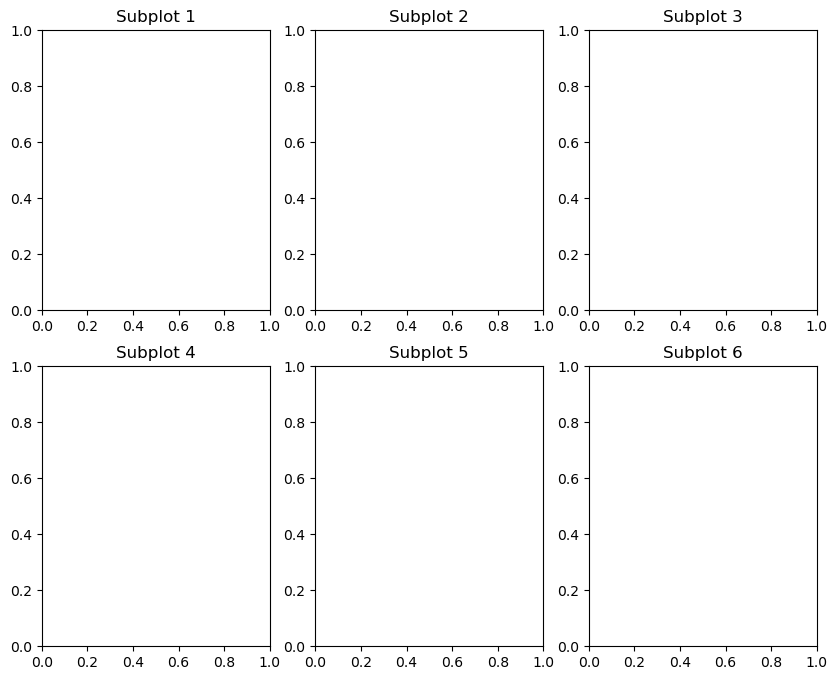

In [32]:
plt.figure(figsize=(10,8))

for i in range(1,7):
    plt.subplot(2,3,i)
    plt.title('Subplot {}'.format(i))

**Exercise:** Create a $3\times 4$ grid of subplots, where the $n^\text{th}$ subplot graphs $y = \cos(nt)$ over the interval $0 \leq t \leq 2\pi$ for $n = 1, 2, \dots, 12$. Add a title to each subplot identifying which function is being graphed.

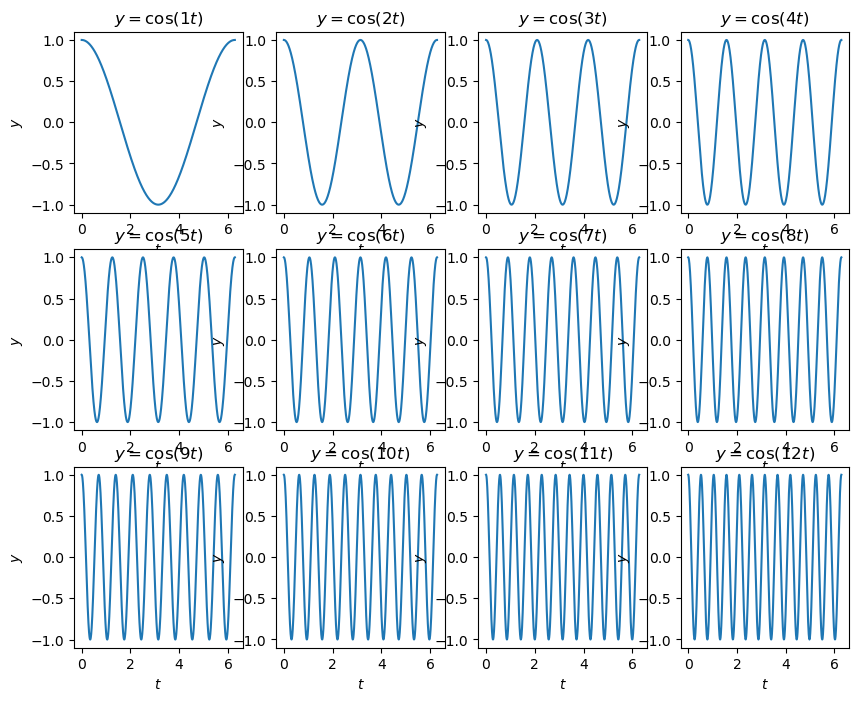

In [37]:
t = np.linspace(0, 2*np.pi, 1000)
plt.figure(figsize=(10, 8))

for n in range(1,13):
    plt.subplot(3,4,n)
    plt.plot(t, np.cos(n*t))
    plt.title('$y = \cos({}t)$'.format(n))
    plt.xlabel('$t$')
    plt.ylabel('$y$')

When creating a figure with subplots, it can often happen that the labels of adjacent subplots will collide. The `plt.tight_layout` function can be called to have `matplotlib` automatically adjust the subplot spacing to try and avoid these collisions and remove extraneous white space.

The `plt.suptitle` function can also be used to add an overall title to a figure with several subplots.

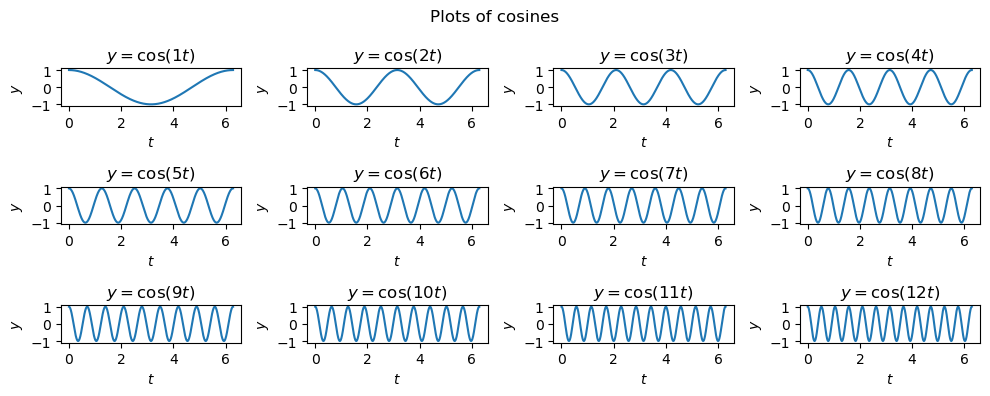

In [46]:
t = np.linspace(0, 2*np.pi, 1000)
plt.figure(figsize=(10, 4))

for n in range(1,13):
    plt.subplot(3,4,n)
    plt.plot(t, np.cos(n*t))
    plt.title('$y = \cos({}t)$'.format(n))
    plt.xlabel('$t$')
    plt.ylabel('$y$')

plt.suptitle('Plots of cosines')
plt.tight_layout()

The arrangment of subplots can be quite flexible. For example, we can add subplots as parts of different sized grid layouts. Suppose we want to add three subplots to a figure, where the first two subplots are side by side at the top of the figure and the third subplot sits below and spans the width of the figure.

We can accomplish this by adding the first two subplots as part of a $2 \times 2$ grid in the first and second positions, then adding the third subplot as part of a $2 \times 1$ grid in the second position.

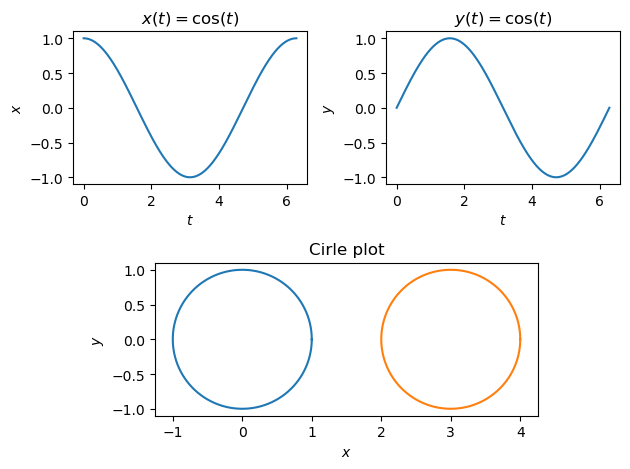

In [50]:
t = np.linspace(0,2*np.pi, 1000)
x = np.cos(t)
y = np.sin(t)

plt.subplot(2,2,1)
plt.plot(t,x)
plt.title('$x(t) = \cos(t)$')
plt.xlabel('$t$')
plt.ylabel('$x$')

plt.subplot(2,2,2)
plt.plot(t,y)
plt.title('$y(t) = \cos(t)$')
plt.xlabel('$t$')
plt.ylabel('$y$')

plt.subplot(2,1,2, aspect='equal')
plt.plot(x,y)
plt.plot(x+ 3,y)
plt.title('Cirle plot')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.tight_layout()

When adding a subplot with `plt.subplot`, the created axes object becomes "active", meaning that all plotting commands (e.g. `plt.plot`, `plt.title`, `plt.legend`, etc.) are directed toward the active axes. Sometimes we may want to go back and activate an earlier axes object to make additional changes. As long as we've stored the desired axes object (e.g. `ax = plt.subplot(...)`), then we can use the `plt.axes` function to re-activate the axes object and continue plotting to it.

Text(30.972222222222214, 0.5, '$x$')

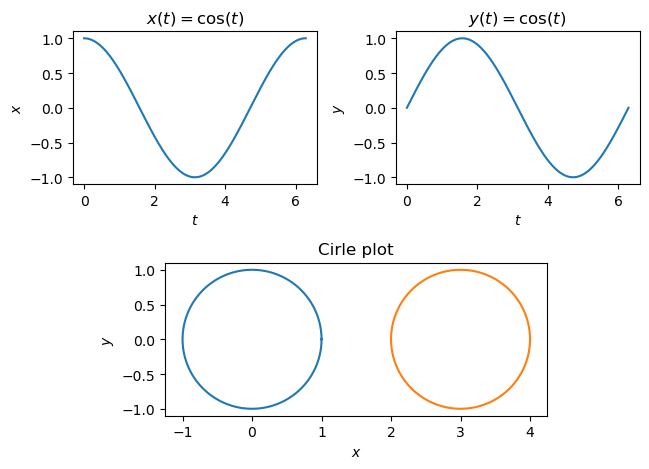

In [53]:
t = np.linspace(0,2*np.pi, 1000)
x = np.cos(t)
y = np.sin(t)

ax = plt.subplot(2,2,1)
plt.plot(t,x)

plt.subplot(2,2,2)
plt.plot(t,y)
plt.title('$y(t) = \cos(t)$')
plt.xlabel('$t$')
plt.ylabel('$y$')

plt.subplot(2,1,2, aspect='equal')
plt.plot(x,y)
plt.plot(x+ 3,y)
plt.title('Cirle plot')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.tight_layout()

plt.axes(ax)
plt.title('$x(t) = \cos(t)$')
plt.xlabel('$t$')
plt.ylabel('$x$')